#Name: Suprim Shrestha
#Student ID: 2418110

# 6CS012 – Workshop1
## Image Compression and Decompression using PCA
**Module:** 6CS012 – Artificial Intelligence and Machine Learning

---

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ── Install required library ──────────────────────────────────────────────────
!pip install pillow --quiet

In [4]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Image path — used throughout the entire notebook
IMAGE_PATH = "/content/drive/MyDrive/dog.jpg"
print("Drive mounted. Image path set to:", IMAGE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Image path set to: /content/drive/MyDrive/dog.jpg


---
## Section 2 – Getting Started with Image Processing
### Exercise 1 – Colour Image Operations

#### Task 1 – Read and Display the Image

Format: None
Mode  : RGB
Size  : (976, 549)   (width x height)
Array shape: (549, 976, 3)   (height x width x channels)


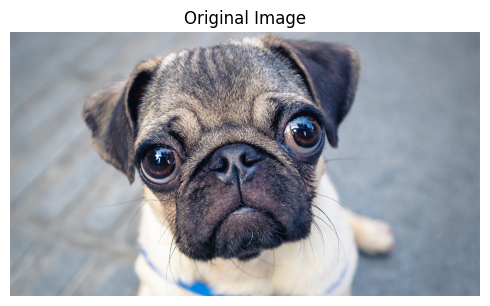

In [5]:
# ── Task 1: Read and display the colour image
image_colored       = Image.open(IMAGE_PATH).convert("RGB")
image_array_colored = np.array(image_colored)

print("Format:", image_colored.format)
print("Mode  :", image_colored.mode)
print("Size  :", image_colored.size, "  (width x height)")
print("Array shape:", image_array_colored.shape, "  (height x width x channels)")

plt.figure(figsize=(5, 5))
plt.imshow(image_array_colored)
plt.title("Original Image")
plt.axis("off")
plt.tight_layout()
plt.show()

#### Task 2 – Display Only the Top-Left 100×100 Pixels

Top-left crop shape: (100, 100, 3)


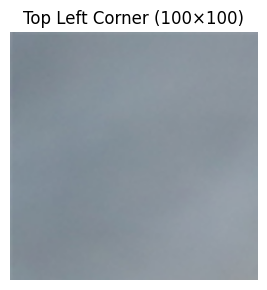

In [6]:
# ── Task 2: Extract top-left 100×100 pixels using NumPy array indexing
# Slice: rows 0-99, columns 0-99, all 3 colour channels
top_left_100 = image_array_colored[:100, :100, :]   # shape → (100, 100, 3)

print("Top-left crop shape:", top_left_100.shape)

plt.figure(figsize=(3, 3))
plt.imshow(top_left_100)
plt.title("Top Left Corner (100×100)")
plt.axis("off")
plt.tight_layout()
plt.show()

#### Task 3 – Show the Three Colour Channels (R, G, B)

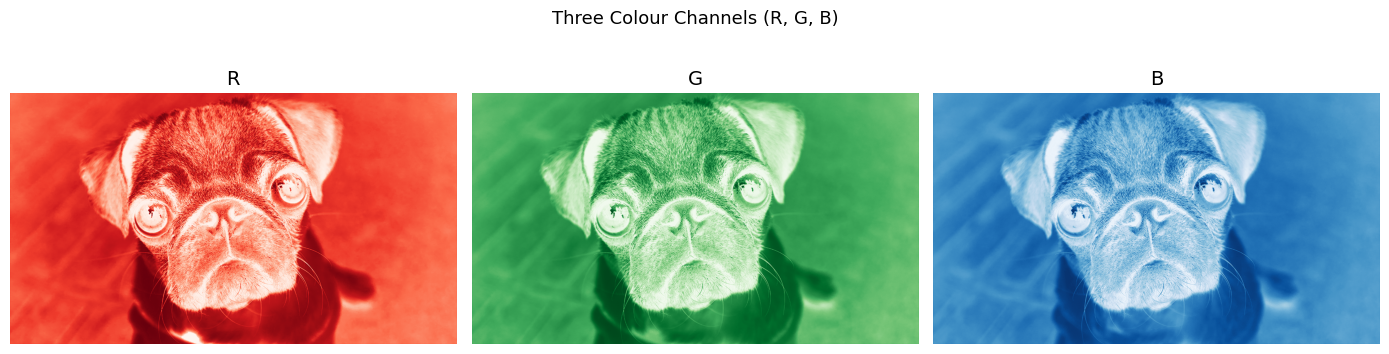

In [7]:
# ── Task 3: Separate channels and display with matplotlib colormaps
# NumPy: last axis selects channel  (0 = Red, 1 = Green, 2 = Blue)
red_channel   = image_array_colored[:, :, 0]   # shape (H, W)
green_channel = image_array_colored[:, :, 1]
blue_channel  = image_array_colored[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# cmap='Reds'/'Greens'/'Blues' creates the coloured backgrounds
# shown in the worksheet Figure 1 sample output
axes[0].imshow(red_channel,   cmap="Reds")
axes[0].set_title("R", fontsize=14)
axes[0].axis("off")

axes[1].imshow(green_channel, cmap="Greens")
axes[1].set_title("G", fontsize=14)
axes[1].axis("off")

axes[2].imshow(blue_channel,  cmap="Blues")
axes[2].set_title("B", fontsize=14)
axes[2].axis("off")

plt.suptitle("Three Colour Channels (R, G, B)", fontsize=13)
plt.tight_layout()
plt.show()

# Note: Using PIL directly would show each channel in grayscale.
# The coloured backgrounds only appear because matplotlib applies the cmap.

#### Task 4 – Modify Top 100×100 Pixels to Value 210

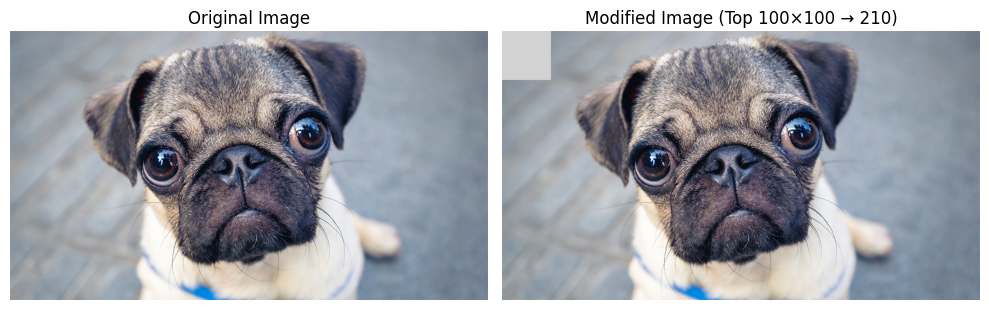

Top-left 100×100 region set to light-grey (value 210 across all 3 channels).


In [8]:
# ── Task 4: Set top-left 100×100 region to pixel value 210 (light grey)
image_modified = image_array_colored.copy()   # copy — do NOT modify original
image_modified[:100, :100, :] = 210           # 210 = light grey (0-255 range)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_array_colored)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(image_modified)
axes[1].set_title("Modified Image (Top 100×100 → 210)")
axes[1].axis("off")

plt.tight_layout()
plt.show()
print("Top-left 100×100 region set to light-grey (value 210 across all 3 channels).")

---
### Exercise 2 – Grayscale Image Operations

#### Task 1 – Load and Display a Grayscale Image

Image shape (grayscale) : (549, 976)
Array shape             : (549, 976)
Pixel range             : min=0,  max=255


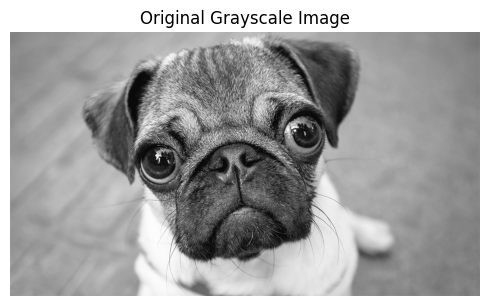

In [9]:
# ── Task 1: Load and display grayscale image
image_grayed       = Image.open(IMAGE_PATH).convert("L")   # 'L' = 8-bit grayscale
image_array_grayed = np.array(image_grayed)                # shape (H, W)

width, height = image_grayed.size
print(f"Image shape (grayscale) : ({height}, {width})")
print(f"Array shape             : {image_array_grayed.shape}")
print(f"Pixel range             : min={image_array_grayed.min()},  max={image_array_grayed.max()}")

plt.figure(figsize=(5, 5))
plt.imshow(image_array_grayed, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.tight_layout()
plt.show()

#### Task 2 – Extract the Middle 150×150 Section

Image centre       : row=274, col=488
Middle crop shape  : (150, 150)


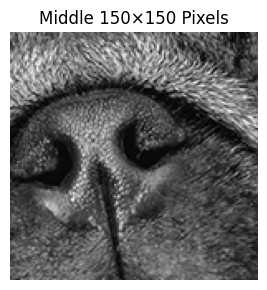

In [10]:
#  Task 2: Extract central 150-pixel section using NumPy array slicing
h, w       = image_array_grayed.shape
center_row = h // 2
center_col = w // 2

# 75 pixels each side of centre → 150×150 region
middle_section = image_array_grayed[
    center_row - 75 : center_row + 75,
    center_col - 75 : center_col + 75
]   # shape → (150, 150)

print(f"Image centre       : row={center_row}, col={center_col}")
print(f"Middle crop shape  : {middle_section.shape}")

plt.figure(figsize=(3, 3))
plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150×150 Pixels")
plt.axis("off")
plt.tight_layout()
plt.show()

#### Task 3 – Apply Threshold (below 100 -> 0, above 100 -> 255)

Unique values after thresholding: [  0 255]


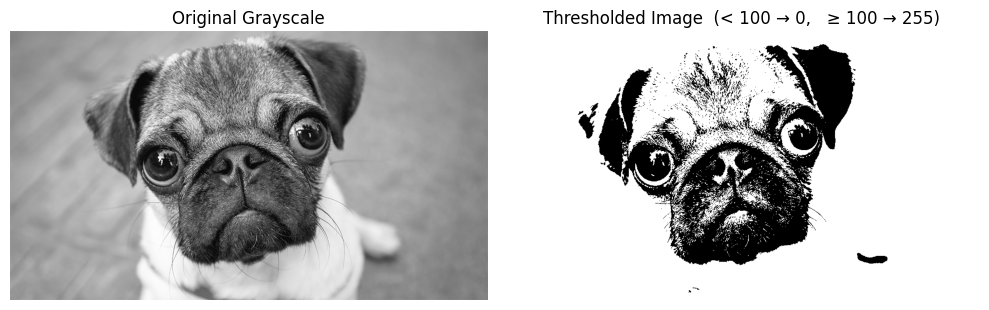

In [11]:
# ── Task 3: Binary threshold
# pixels <  100 → 0   (black)
# pixels >= 100 → 255 (white)
image_threshold = np.where(image_array_grayed >= 100, 255, 0).astype(np.uint8)

print("Unique values after thresholding:", np.unique(image_threshold))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_array_grayed, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

axes[1].imshow(image_threshold, cmap="gray")
axes[1].set_title("Thresholded Image  (< 100 → 0,   ≥ 100 → 255)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Task 4 – Rotate Image 90° Clockwise

Original shape : (549, 976)
Rotated shape  : (976, 549)


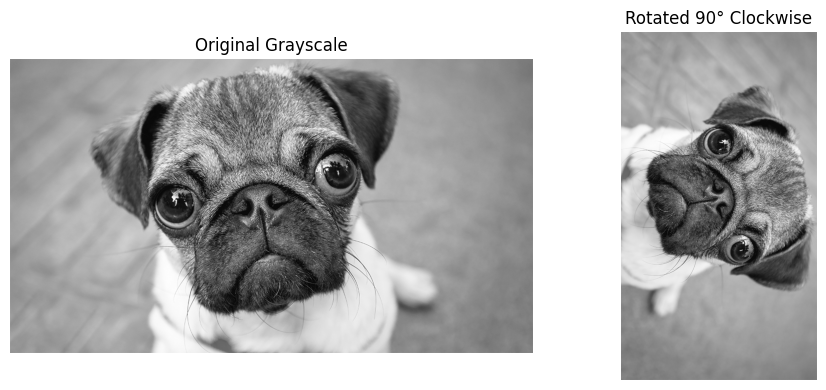

In [12]:
# Task 4: Rotate 90° clockwise
# PIL rotate() is counter-clockwise — pass -90 to get clockwise
# expand=True adjusts canvas size for non-square images
image_rotated       = image_grayed.rotate(-90, expand=True)
image_rotated_array = np.array(image_rotated)

# NumPy equivalent:  np.rot90(image_array_grayed, k=-1)

print(f"Original shape : {image_array_grayed.shape}")
print(f"Rotated shape  : {image_rotated_array.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_array_grayed,   cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

axes[1].imshow(image_rotated_array,  cmap="gray")
axes[1].set_title("Rotated 90° Clockwise")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Task 5 – Convert Grayscale to RGB

Grayscale shape : (549, 976)
RGB shape       : (549, 976, 3)
All 3 channels are identical — grayscale values replicated across R, G, B.


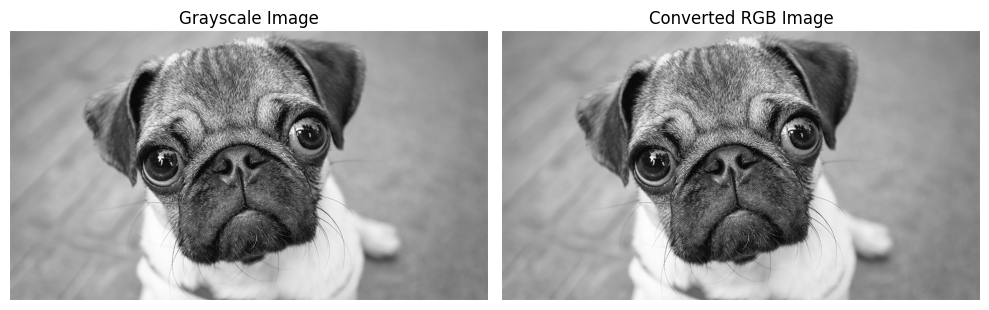

In [13]:
# Task 5: Convert grayscale to RGB by replicating the single channel
# np.stack([arr]*3, axis=-1) creates shape (H, W, 3)
# Each of the 3 channels gets the same grayscale intensity values
image_rgb_from_gray = np.stack([image_array_grayed] * 3, axis=-1)   # (H, W, 3)

print(f"Grayscale shape : {image_array_grayed.shape}")
print(f"RGB shape       : {image_rgb_from_gray.shape}")
print("All 3 channels are identical — grayscale values replicated across R, G, B.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_array_grayed, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis("off")

axes[1].imshow(image_rgb_from_gray)
axes[1].set_title("Converted RGB Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

---
## Section 3 – Image Compression using PCA (Built from Scratch)

> **PCA is implemented entirely with NumPy — no `sklearn` is used anywhere.**

### Step 1 – Load Image, Convert to Grayscale, and Standardise

In [14]:
# Step 1: Load image, convert to grayscale float64, centre the data
img_pca = Image.open(IMAGE_PATH).convert("L")
X       = np.array(img_pca, dtype=np.float64)    # shape (H, W)

print(f"Image shape : {X.shape}   (height × width)")
print(f"Pixel range : min={X.min():.0f},  max={X.max():.0f}")

# Centre: subtract the mean of each column (pixel position)
mean      = np.mean(X, axis=0)     # shape (W,)
X_centered = X - mean              # shape (H, W) — broadcast subtracts column means

print(f"\nBefore centering — mean of column 0 : {X[:, 0].mean():.2f}")
print(f"After  centering — mean of column 0 : {X_centered[:, 0].mean():.8f}  (≈ 0)")

Image shape : (549, 976)   (height × width)
Pixel range : min=0,  max=255

Before centering — mean of column 0 : 152.61
After  centering — mean of column 0 : -0.00000000  (≈ 0)


### Step 2 – Compute the Covariance Matrix

In [15]:
#  Step 2: Covariance matrix — computed from scratch
# Formula:  C = (1 / (n-1)) * X_centered^T · X_centered
# n = number of rows (image rows = samples)
n          = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)   # shape (W, W)

print(f"Covariance matrix shape      : {cov_matrix.shape}")
print(f"Matrix is symmetric          : {np.allclose(cov_matrix, cov_matrix.T)}")
print(f"First 5 diagonal (variances) : {np.diag(cov_matrix)[:5].round(2)}")

Covariance matrix shape      : (976, 976)
Matrix is symmetric          : True
First 5 diagonal (variances) : [57.39 63.64 64.31 63.4  62.8 ]


### Step 3 – Eigen Decomposition and Identifying Principal Components

In [16]:
#  Step 3a: Eigenvalues and eigenvectors
# np.linalg.eigh is designed for symmetric matrices — more stable than eig
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# eigh returns ASCENDING order — reverse to get DESCENDING
sorted_idx    = np.argsort(eigenvalues)[::-1]
eigenvalues   = eigenvalues[sorted_idx]
eigenvectors  = eigenvectors[:, sorted_idx]    # each column = one eigenvector

print(f"Total eigenvalues         : {len(eigenvalues)}")
print(f"Top 5 eigenvalues         : {eigenvalues[:5].round(2)}")
print(f"Eigenvector matrix shape  : {eigenvectors.shape}")

Total eigenvalues         : 976
Top 5 eigenvalues         : [716171.11 571436.   176355.53 132654.01 101159.88]
Eigenvector matrix shape  : (976, 976)


Components needed to reach variance thresholds:
  80%  →  7 components
  90%  →  20 components
  95%  →  53 components
  99%  →  157 components


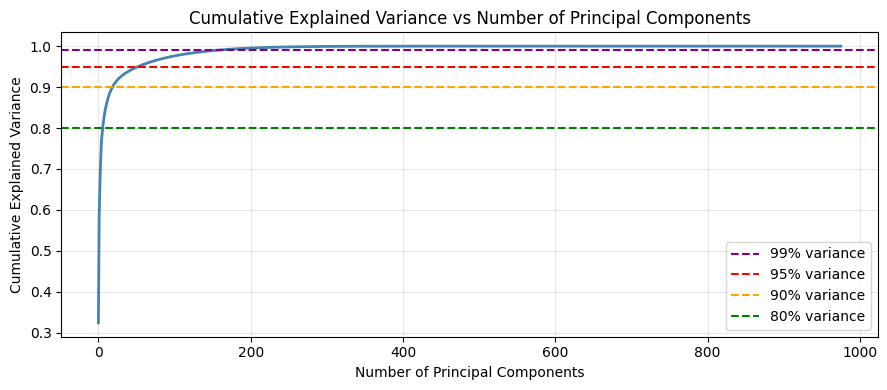

In [17]:
# Step 3b: Cumulative Explained Variance Plot
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance      = np.cumsum(explained_variance_ratio)

print("Components needed to reach variance thresholds:")
for threshold in [0.80, 0.90, 0.95, 0.99]:
    k = int(np.argmax(cumulative_variance >= threshold)) + 1
    print(f"  {int(threshold*100)}%  →  {k} components")

plt.figure(figsize=(9, 4))
plt.plot(cumulative_variance, color="steelblue", linewidth=2)
plt.axhline(y=0.99, color="purple", linestyle="--", label="99% variance")
plt.axhline(y=0.95, color="red",    linestyle="--", label="95% variance")
plt.axhline(y=0.90, color="orange", linestyle="--", label="90% variance")
plt.axhline(y=0.80, color="green",  linestyle="--", label="80% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Number of Principal Components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 4 – Reconstruction Function

In [18]:
#  Step 4: PCA reconstruction function — from scratch, no sklearn
def pca_reconstruct(X_centered, eigenvectors, mean, k):
    """
    Compress and reconstruct a grayscale image using PCA.

    Parameters
    ----------
    X_centered  : ndarray (H, W)  — mean-centred image
    eigenvectors: ndarray (W, W)  — columns = eigenvectors, sorted descending
    mean        : ndarray (W,)    — per-column mean of original image
    k           : int             — number of principal components to keep

    Returns
    -------
    ndarray (H, W) uint8          — reconstructed image clipped to [0, 255]

    Steps
    -----
    1. W_k = eigenvectors[:, :k]        select top-k PCs       shape (W, k)
    2. Z   = X_centered @ W_k           project (compress)     shape (H, k)
    3. X_hat = Z @ W_k.T + mean         back-project + centre  shape (H, W)
    """
    W_k          = eigenvectors[:, :k]          # top-k principal components
    Z            = X_centered @ W_k             # compressed representation
    X_hat        = Z @ W_k.T + mean             # reconstruct to original space
    return np.clip(X_hat, 0, 255).astype(np.uint8)


print("pca_reconstruct() defined.")

pca_reconstruct() defined.


### Step 5 – Experiments: Four Different k Values

k =   10  |  Explained variance: 84.5%
k =   20  |  Explained variance: 90.2%
k =   50  |  Explained variance: 94.8%
k =  100  |  Explained variance: 97.6%


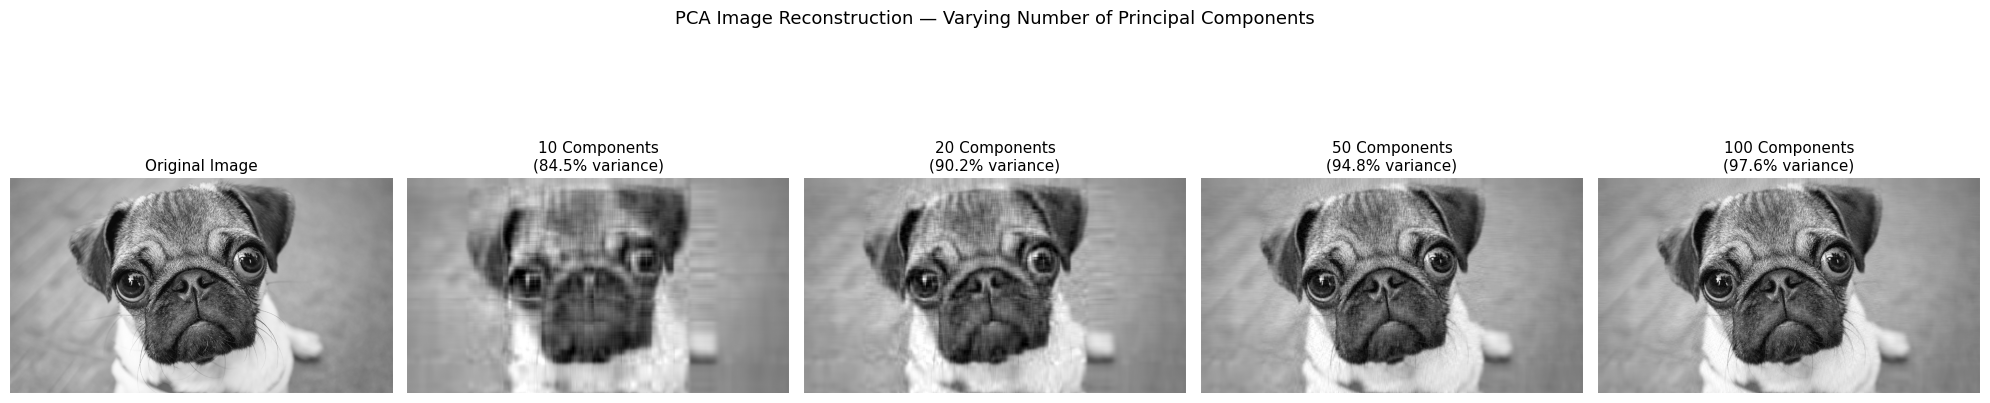

In [19]:
# Step 5: Reconstruct with k = 10, 20, 50, 100 and compare
k_values = [10, 20, 50, 100]   # four combinations as required by worksheet

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# First panel — original image
axes[0].imshow(X.astype(np.uint8), cmap="gray")
axes[0].set_title("Original Image", fontsize=11)
axes[0].axis("off")

# Remaining panels — reconstructed images
for i, k in enumerate(k_values):
    recon         = pca_reconstruct(X_centered, eigenvectors, mean, k)
    var_explained = cumulative_variance[k - 1] * 100

    axes[i + 1].imshow(recon, cmap="gray")
    axes[i + 1].set_title(f"{k} Components\n({var_explained:.1f}% variance)", fontsize=11)
    axes[i + 1].axis("off")

    print(f"k = {k:4d}  |  Explained variance: {var_explained:.1f}%")

plt.suptitle("PCA Image Reconstruction — Varying Number of Principal Components",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Step 6 – Display Results and Evaluate (MSE + Compression Ratio)

In [20]:
# Step 6: Quantitative evaluation
H, W          = X.shape
original_size = H * W

print(f"{'k':>5}  {'Variance':>10}  {'MSE':>10}  {'Compression':>14}")
print("-" * 46)

for k in k_values:
    recon             = pca_reconstruct(X_centered, eigenvectors, mean, k)
    mse               = np.mean((X - recon.astype(np.float64)) ** 2)
    var_explained     = cumulative_variance[k - 1] * 100
    # Compressed storage = projection scores (H*k) + eigenvectors (W*k) + mean (W)
    compressed_size   = H * k + W * k + W
    compression_ratio = original_size / compressed_size

    print(f"{k:5d}  {var_explained:9.1f}%  {mse:10.2f}  {compression_ratio:12.2f}x")

print("\nConclusions:")
print("  Higher k  → lower MSE (better quality), weaker compression.")
print("  Lower  k  → higher compression, more information lost.")
print("  The cumulative variance plot reveals the sweet-spot.")

    k    Variance         MSE     Compression
----------------------------------------------
   10       84.5%      351.11         33.02x
   20       90.2%      221.57         17.02x
   50       94.8%      118.58          6.94x
  100       97.6%       54.70          3.49x

Conclusions:
  Higher k  → lower MSE (better quality), weaker compression.
  Lower  k  → higher compression, more information lost.
  The cumulative variance plot reveals the sweet-spot.
